This notebook performs an Exploratory Data Analysis (EDA) on the 2025 New York City 311 service requests dataset. The 311 system serves as the primary channel for New Yorkers to report non-emergency civic issues, ranging from noise complaints and infrastructure damage to housing violations. By analyzing this data, we aim to uncover seasonal trends, operational bottlenecks, and geographic hotspots of citizen concerns throughout 2025.

Here you can Dowload the Data. If you already have the data make sure its named "nyc311_2025.csv".

In [1]:
import os
import requests

# Downloads the data only if the file does not exist locally
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"
params = {
    "$where": "created_date >= '2025-01-01T00:00:00' AND created_date < '2026-01-01T00:00:00'",
    "$limit": 5000000,
}
filename = "nyc311_2025.csv"

if not os.path.exists(filename):
    print("Downloading data...")
    r = requests.get(url, params=params)
    with open(filename, "wb") as f:
        f.write(r.content)
    print("done")
else:
    print("Data already exists locally. Skipping download.")

Data already exists locally. Skipping download.


**Auditing**

For the start, i will audit and clean the data to make sure all the information is in the form and scope of what we expect.

Before loading the full dataset, I work with a subset of the rows to keep memory usage low. I use this subset for two things: getting familiar with what each column looks like, and measuring how complete each column is (the share of missing values). Missingness is stable across the dataset, so a subset is enough to decide which columns are too sparse to keep. The value counts shown here are just to illustrate the columns — I don't draw conclusions from them, and any distribution I actually rely on later is recomputed on the full data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("nyc311_2025.csv", nrows=50000)
df.shape

/tmp/ipykernel_3075/3391233020.py:5: DtypeWarning: Columns (0: taxi_company_borough, 1: bridge_highway_direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("nyc311_2025.csv", nrows=50000)


(50000, 44)

In [3]:
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,67351762,2025-12-31T23:59:28.000,2026-01-01T00:40:32.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10029.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.792141,-73.950097,POINT (-73.950097072847 40.792140506424)
1,67344624,2025-12-31T23:59:23.000,2026-01-01T01:03:42.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10031.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.825137,-73.949447,POINT (-73.949447237231 40.82513729001)
2,67346873,2025-12-31T23:59:21.000,2026-01-01T00:58:13.000,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11234.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.619995,-73.921167,POINT (-73.921167390534 40.619994693785)
3,67353004,2025-12-31T23:59:20.000,2026-01-01T00:57:31.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,11235.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.591542,-73.955979,POINT (-73.955979130812 40.591541524842)
4,67350526,2025-12-31T23:59:12.000,2026-01-01T00:41:16.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,Store/Commercial,10031.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.822593,-73.949525,POINT (-73.949525045155 40.822592971648)


**Collumns**

Now lets get familiar with the most important columns for the analisys and plots.

*Unique Key*

Unique identifier of a Service Request (SR) in the open data set

In [4]:
df['unique_key'].sample(3)

46313    67303129
47898    67305438
13476    67337961
Name: unique_key, dtype: int64

*Created date and Closed date*

this as the name says, shows the date and time of the request (should be mandatory) and the date and time of when the request was closed (optional).

In [5]:
print(df['created_date'].sample(2))
print(df['closed_date'].sample(2))

26855    2025-12-29T07:56:12.000
47873    2025-12-26T15:47:49.000
Name: created_date, dtype: str
14659    2025-12-30T12:21:36.000
32084    2025-12-29T20:36:51.000
Name: closed_date, dtype: str


*Agency and Agency Name*

this is the Acronym or Full Agency Name of responding City Government Agency, each one has its own match.


In [6]:
print(df['agency'].unique())
print(df['agency_name'].unique())

<ArrowStringArray>
[ 'NYPD',   'TLC',   'HPD',   'DOB',   'DOT',  'DSNY',  'DCWP',   'DEP',
   'DPR',   'EDC', 'DOHMH',   'OOS',   'DHS',   'DOE',   'OTI']
Length: 15, dtype: str
<ArrowStringArray>
[                   'New York City Police Department',
                      'Taxi and Limousine Commission',
 'Department of Housing Preservation and Development',
                            'Department of Buildings',
                       'Department of Transportation',
                           'Department of Sanitation',
       'Department of Consumer and Worker Protection',
             'Department of Environmental Protection',
                 'Department of Parks and Recreation',
                   'Economic Development Corporation',
            'Department of Health and Mental Hygiene',
                              'Office of the Sheriff',
                    'Department of Homeless Services',
                            'Department of Education',
                'Office of Techn

*City and Borough*

this is the biggest generalization of the location of the requirement. Borough is more general while City is more specific and unreliable, for example in City, Manhattan in double counted in NEW YORK and MANHATTAN while also dividing into regions without a solid defition.

In [7]:
print(df['city'].value_counts().head())
print(df['borough'].value_counts().head())

city
BROOKLYN         14859
BRONX            11076
NEW YORK          9010
STATEN ISLAND     1840
JAMAICA           1284
Name: count, dtype: int64
borough
BROOKLYN         15259
QUEENS           11746
BRONX            11255
MANHATTAN         9783
STATEN ISLAND     1929
Name: count, dtype: int64


*Status*

status is a simple short string that shows the Progress of the request.
Since the data is from 2025 you can expect correctly that most are Closed. But there are other values that appear frequently, like In Progress, Open, Pending...

In [8]:
df['status'].value_counts()

status
Closed         48990
In Progress      622
Open             194
Assigned         107
Pending           58
Started           28
Unspecified        1
Name: count, dtype: int64

*Complaint type and Descriptor*

Those are the fisrt and second level of Hierarchy describing the problem, Complaint type is less categorized and easier to deal with

In [9]:
print(df['complaint_type'].value_counts()[1:4])
print(df['descriptor'].value_counts()[1:4])


complaint_type
Illegal Parking        6667
Noise - Residential    5249
Blocked Driveway       2691
Name: count, dtype: int64
descriptor
APARTMENT ONLY      4034
Loud Music/Party    3157
Banging/Pounding    2688
Name: count, dtype: int64


Analysing Columns Nan ratio in the subset.

In [10]:
df.isna().mean() * 100

unique_key                         0.000
created_date                       0.000
closed_date                        1.792
agency                             0.000
agency_name                        0.000
complaint_type                     0.000
descriptor                         1.168
descriptor_2                      49.492
location_type                     10.510
incident_zip                       0.852
incident_address                   3.522
street_name                        3.522
cross_street_1                    43.878
cross_street_2                    43.854
intersection_street_1             45.704
intersection_street_2             45.662
address_type                       0.474
city                               3.266
landmark                          51.514
facility_type                     99.824
status                             0.000
due_date                          99.712
resolution_description             1.804
resolution_action_updated_date     1.086
community_board 

**Cleaning**

Since this the dull DataSet is very specified and Heavy, with over 3 million rows and 44 collumns, i took the decision of only keeping the columns that are essential to the Analisys, dropping the ones that have a high Nan ratio and or are redundant considering there is another column that exemplifies the Data better. I chose to keep [unique key, created_date, closed_date, agency, borough, status, complaint_type, police_precinct, latitude, longitude]. This will generate a cleaner and lighter Data for performance.

In [11]:
import gc

del df
gc.collect()

df = pd.read_csv("nyc311_2025.csv", usecols= ['unique_key', 'created_date', 'closed_date', 'agency', 'borough',
                 'status', 'complaint_type', 'police_precinct', 'latitude', 'longitude'])
df.shape

(3655034, 10)

*Checking for correct types*

Are the types in the most important columns we are analysing, matching the types of what we expect them to be?

In [12]:
date_columns = ['created_date', 'closed_date']
number_columns = ['unique_key', 'latitude', 'longitude']
string_columns = ['status', 'agency', 'complaint_type', 'borough']

print(df[date_columns].dtypes.isin([np.dtype('<M8[us]'), np.dtype('<M8[ns]')]).all())
print(df[number_columns].dtypes.isin([np.dtype('int64'), np.dtype('float64')]).all())
print(df[string_columns].dtypes.isin(['object', pd.StringDtype()]).all())

False
True
False


Checking and correcting dtypes from date and string columns


In [13]:
print(df[date_columns].dtypes)
print(df[string_columns].dtypes)

created_date    str
closed_date     str
dtype: object
status            str
agency            str
complaint_type    str
borough           str
dtype: object


In [14]:
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[string_columns] = df[string_columns].astype(object)

In [15]:
print(df[date_columns].dtypes)
print(df[string_columns].dtypes)

created_date    datetime64[us]
closed_date     datetime64[us]
dtype: object
status            object
agency            object
complaint_type    object
borough           object
dtype: object


Now the types are matching what we expect and we probably arent going to have any surprises in the future.

checking for any dates outside the range on 2025 and or any null values on created date:
also checking for negative delta dates that have the closed date before created date.

In [16]:
outside_range = (df['created_date'] < '2025-01-01T00:00:00.000') | (df['created_date'] > '2025-12-31T23:59:59.999')
print(outside_range.any())
print(df['created_date'].isna().any())

inconsistent_timed = (df["created_date"] > df["closed_date"])
print(inconsistent_timed.any())
print(df[inconsistent_timed].loc[:, ['unique_key', 'created_date', 'closed_date']].sample(1))


False
False
True
         unique_key        created_date         closed_date
3349378    63907343 2025-01-27 12:02:00 2025-01-24 12:02:00


Its possible to see that there are inconsistent timed Rows. And since they will provide incorrect results i will drop them. 

In [17]:
df = df[~inconsistent_timed]

Checking for duplicate rows using the Unique key

In [18]:
df.duplicated(subset=['unique_key']).sum().any()

np.False_

**Analysis**

Now that we assured our data is cleaner, we can start plotting and investigating it.

What is the total volume of *valid* regitered issues?

In [19]:
df.shape

(3654120, 10)

In those 3.654.120 requests, what are the days of the months and of the week with the biggest peak of requests?

In [20]:
df['month'] = df['created_date'].dt.month

month_map = {
    1: "January", 2: "February", 3: "March", 
    4: "April", 5: "May", 6: "June", 7: "July", 
    8: "August", 9: "September", 10: "October", 11: "November", 
    12: "December"
}

df['month'] = df['month'].map(month_map)

<Axes: title={'center': 'Amount of requests per Month'}, xlabel='month', ylabel='count'>

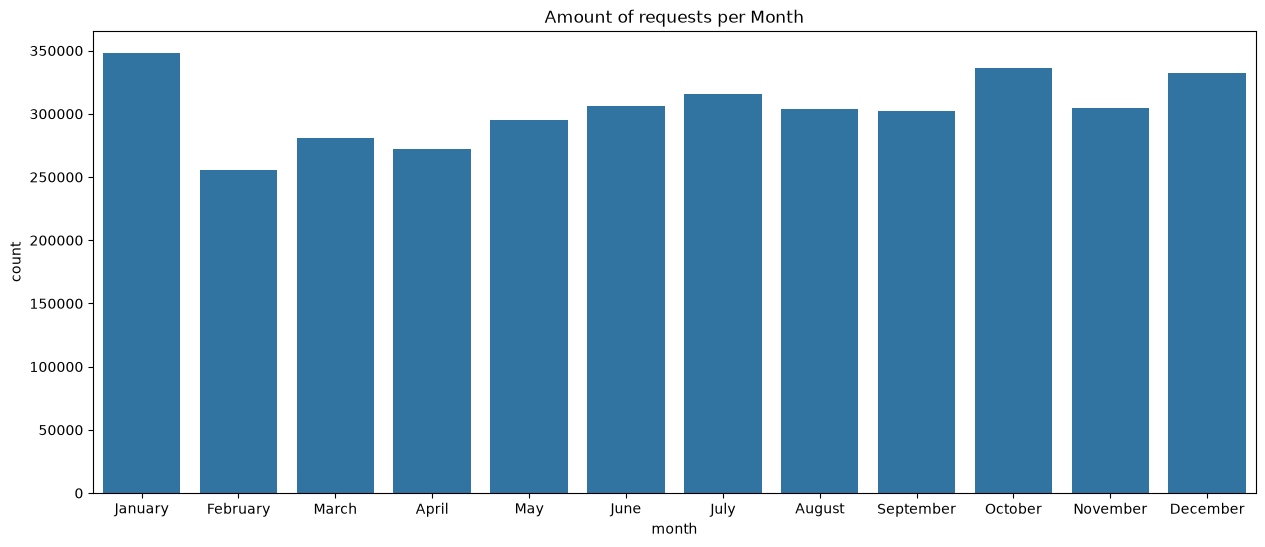

In [21]:
import matplotlib.pyplot as plt

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(15, 6))
plt.title("Amount of requests per Month")
sns.countplot(data=df, x='month', order=month_order)

<Axes: title={'center': 'Amount of requests per day of the week'}, xlabel='week_day', ylabel='count'>

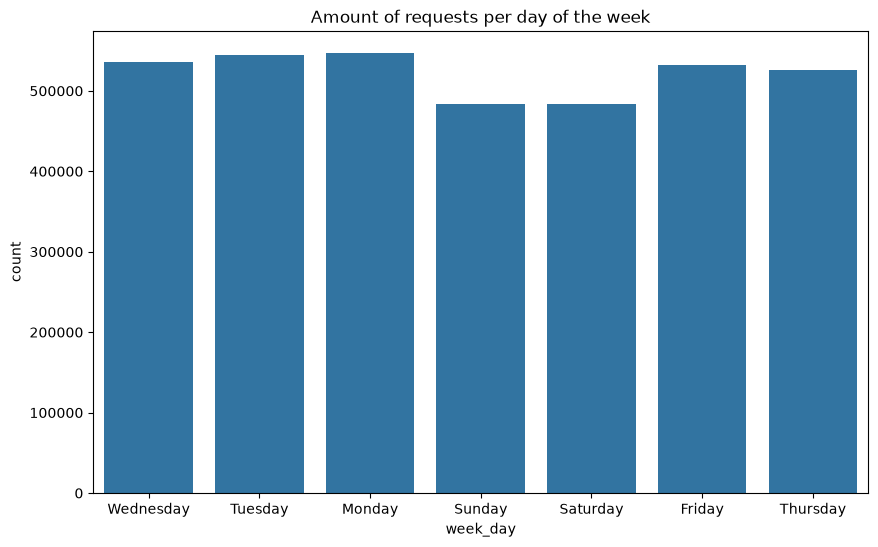

In [22]:
df['week_day'] = df['created_date'].dt.day_name()
plt.figure(figsize=(10, 6))
plt.title("Amount of requests per day of the week")
sns.countplot(data=df, x='week_day')

Its possible to notice that January has a higher peak of requests with a big drop following the next months, and that Saturday and Sunday have less requests. to the second insight its possible that the reason is, since more people tend to stay at home during those days, consequently they have a smaller chance of making a request. But for the monthly insight, i dont know the reason so lets look into deeper.


In [23]:
#top 5 most complaint values in the month of january normaliazed to 30 days.
total_days_in_period = 31
((df[df['month'] == 'January']['complaint_type'].value_counts()[:5]) / 31) * 30

complaint_type
Noise - Residential     68551.935484
HEAT/HOT WATER          65060.322581
Illegal Parking         41747.419355
Blocked Driveway        14188.064516
UNSANITARY CONDITION     9677.419355
Name: count, dtype: float64

In [24]:
#top 5 most complaint values in the month of february, mach and april, on average and normaliazed to 30 days.
total_days_in_period = 89
(df[df['month'].isin(['February', 'March', 'April'])]['complaint_type'].value_counts()[:5] / total_days_in_period) * 30

complaint_type
Illegal Parking            48325.280899
Noise - Residential        28251.910112
HEAT/HOT WATER             28246.853933
Blocked Driveway           13357.078652
Noise - Street/Sidewalk     8669.662921
Name: count, dtype: float64

Its noticeable that the amount of complaints about Noise in residential areas, and problems with heating systems have a spike on January compared to the average of the 3 following months. I have an hypothesis that this can be caused by the new years/ vacations parties and heavy winter.

<Axes: title={'center': 'Amount of Noise - Residential complaints per day in January 2025'}, xlabel='day', ylabel='count'>

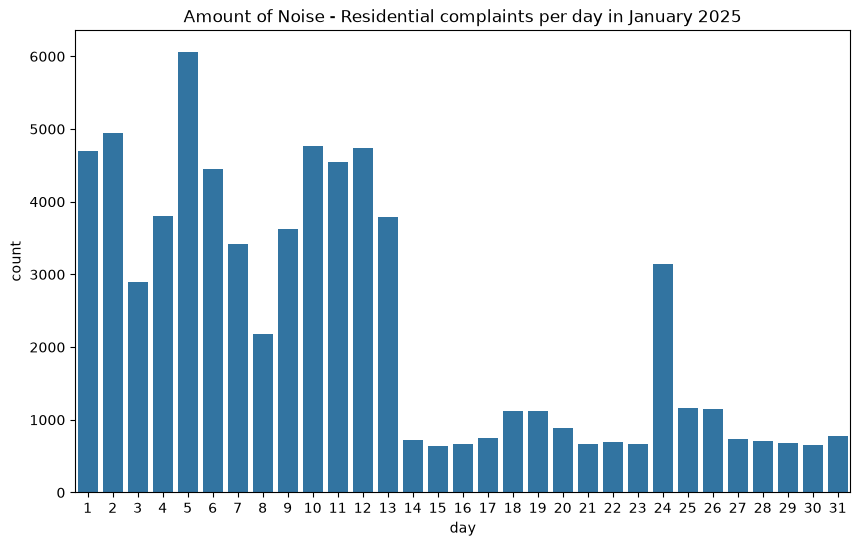

In [25]:
df['day'] = df['created_date'].dt.day
plt.figure(figsize=(10, 6))
plt.title("Amount of Noise - Residential complaints per day in January 2025")
sns.countplot(data=df, x=df[(df['month'] == 'January') & (df['complaint_type'] == 'Noise - Residential')]['day'])

January noise complaints are elevated across roughly the first third of the month, with also a clear spike on day 24, not just around New Year's, so a simple 'holiday parties' explanation doesn't fully account for it.

If heating problems are much more likely to appear in the winter, complaints have a increase in summertime at NYC? Or better, wich of the most requested complaint types have a higher variance troughout the year?

In [82]:
monthly_count = df.groupby(['complaint_type', 'month']).size().reset_index(name='count')

In [83]:
monthly_count = monthly_count.pivot(index='complaint_type', columns='month', values='count').fillna(0)

In [88]:
complaint_variance = monthly_count.var(axis=1).sort_values(ascending=False)
print(complaint_variance.head(5))


complaint_type
HEAT/HOT WATER             5.756709e+08
Noise - Residential        1.971511e+08
Noise - Street/Sidewalk    6.684133e+07
Water System               1.784127e+07
Illegal Parking            1.530757e+07
dtype: float64


So Heating realated complaints have a much higher variance, wich makes sense considering the temperature variance in NYC, but noise and water systems also are at the top. lest see how they vary troughout the year.

In [90]:
top_categories = ['HEAT/HOT WATER', 'Noise - Residential', 'Noise - Street/Sidewalk', 'Water System']
filtered = monthly_count.loc[top_categories]
filtered = filtered[month_order]
filtered = filtered.T

In [86]:
#normalizing monthly values 30 days.
months_2025 = pd.date_range(start="2025-01-01", periods=12, freq="MS")
days_series = pd.Series(data=months_2025.days_in_month, index=months_2025.strftime('%B'))

filtered = filtered.div(days_series, axis=0)
filtered *= 30

<Axes: title={'center': 'Tendency of top variance reports troughout the year'}, xlabel='month', ylabel='count'>

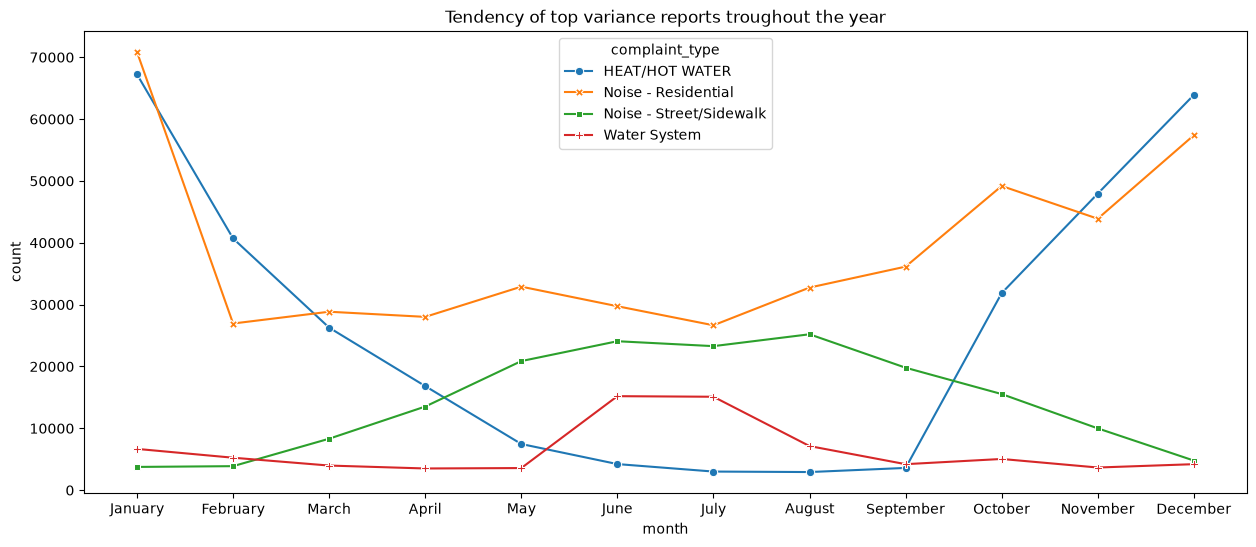

In [91]:
plt.figure(figsize=(15, 6))
plt.ylabel("count")
plt.title("Tendency of top variance reports troughout the year")
sns.lineplot(data=filtered, markers=True, dashes=False, )

In this plot its clearly visible those seasonal trends, like heating having a high peak on winter and a giant drop in summer, while Water system complaints have a cliff in peak summer (June, July). And noise complaints types have a inverse seasonality, one plausible explanation is because of temperature/culture, more people say at residential areas in the year extremes and at the street on the middle of the year, changing the behavior of complaints, but this is just a hypothesis and not confirmed by the data.

Lets see if the data can shows us any gaps on NYC operations.

First i will calculate the difference in Created date and closed date. Formatting by hours in a float.

In [95]:
df['time_diff'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600

Now how much time each agency take on average to close a report?

In [99]:
agency_timediff = df.groupby('agency').time_diff.mean().sort_values(ascending=False)
agency_timediff

agency
EDC      7044.602918
DOE      2851.461444
TLC      2083.542320
DOB      1263.076037
DPR      1056.782206
OOS       973.204206
DOHMH     497.758856
OTI       413.051652
DCWP      371.530411
HPD       367.015274
DOT       230.655968
DHS       111.908928
DSNY       89.213825
DEP        83.638146
NYPD        2.964204
Name: time_diff, dtype: float64

the EDC (Economic development corporation) takes the longest to close a request, while the NYPD (NYC police) takes by far the least, wich makes sense considering the nature of each agency.

Lets take a look at the DOT (Department of Transportation). I wonder if i takes longer to them to solve a complaint depending on the Borough.

In [ ]:
time_diff_odt = df[df['agency'] == 'DOT'].groupby(['borough']).time_diff.mean()

<Axes: title={'center': 'Time for resolution of DOT requests, by borough'}, xlabel='borough', ylabel='time_diff'>

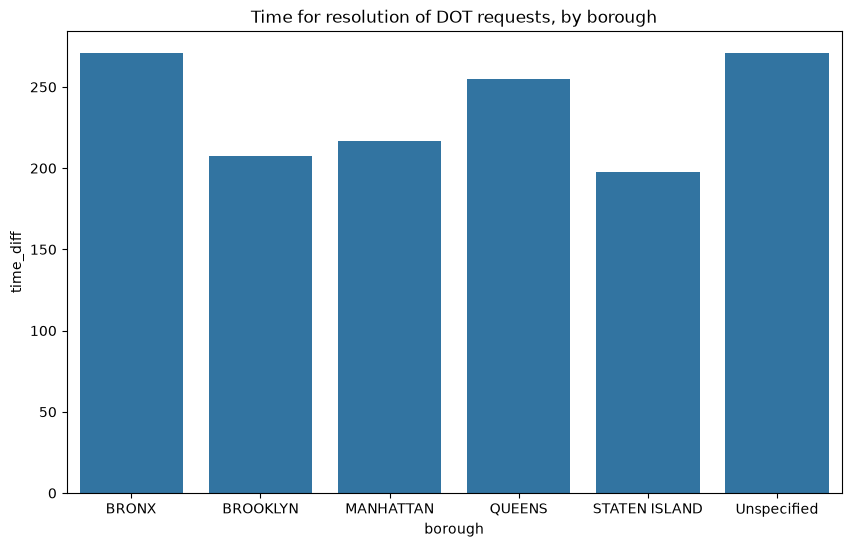

In [128]:
plt.figure(figsize=(10, 6))
plt.title("Time for resolution of DOT requests, by borough")
sns.barplot(x=time_diff_odt.index, y=time_diff_odt)

So Bronx, Queens and Unspecified areas take longer to solve transit requests than on Brooklyn, Manhattan and Staten Island.
Lets see if the types of complaints are different on those areas.

In [148]:
df[(df['agency'] == 'DOT') & (df['borough'].isin(['BRONX', 'QUEENS', 'Unspecified']))]['complaint_type'].value_counts().head()

complaint_type
Street Condition            33069
Traffic Signal Condition    19063
Street Light Condition      14586
Sidewalk Condition          11236
Curb Condition               2784
Name: count, dtype: int64

In [146]:
df[(df['agency'] == 'DOT') & (df['borough'].isin(['BROOKLYN', 'MANHATTAN', 'STATEN ISLAND']))]['complaint_type'].value_counts().head()

complaint_type
Street Condition            37255
Traffic Signal Condition    28932
Street Light Condition      18425
Sidewalk Condition          14573
Curb Condition               5286
Name: count, dtype: int64

Ok, so there isnt much difference on DOT request types depending on the Area, so the time for resolution difference isnt because of that.

Lets take a look in what types of requests, troughout all agencies still have an OPEN status

In [160]:
df[df['status'].isin(['Open'])]['complaint_type'].value_counts().head()

complaint_type
HEAT/HOT WATER                   1532
Building/Use                      711
General Construction/Plumbing     631
Sewer                             518
Water System                      480
Name: count, dtype: int64

Looks like housing problemns are the ones that have more OPEN status. Lets see if the % of Open requests per agencies back that claim

In [162]:
df[df['status'].isin(['Open'])]['agency'].value_counts().div(df['agency'].value_counts()) * 100

agency
DCWP          NaN
DEP      0.586901
DHS           NaN
DOB      1.664985
DOE           NaN
DOHMH         NaN
DOT      0.026506
DPR           NaN
DSNY     0.111086
EDC           NaN
HPD      0.422065
NYPD          NaN
OOS           NaN
OTI           NaN
TLC           NaN
Name: count, dtype: float64

Ok, so the agency with most open requests is by far DOB (Department of Buildings), with around 1.6% of valid requests being left OPEN. DEP (deparment of enviromental protection) and HPD (Housing preservation and development) also have a higher value. Considering that its possible to see that those agencies all deal with infrastructure problemns, pointing to a possible bottleneck in NYC.